## Uitleg volledige scriptworkflow
Deze notebook bouwt stap voor stap een **slide-based model** voor vrije en geforceerde trillingen van de windturbinestructuur.

### 1) Invoer en parameters
- Definieert geometrie, materiaal, massa's, waterdichtheden en modelcoëfficiënten.
- Berekent afgeleide grootheden zoals doorsnede $A$, traagheidsmoment $I$, en lijnmassa's onder/boven water.

### 2) Vrije trillingen (eigenanalyse)
- Stelt per segment een Euler-Bernoulli oplossing op: onder water ($W_1$) en boven water ($W_2$).
- Vormt rand- en interfacevoorwaarden in matrixvorm $K(\omega)\,c=0$.
- Zoekt natuurlijke frequenties via minima van $\sigma_{\min}(K(\omega))$.
- Bepaalt mode-constanten met SVD en plot de eerste 3 modusvormen.

### 3) Steady-state respons volgens (1.41)–(1.58)
- Definieert dispersie, forcing-termen en parameters $\beta_s^4$, $\beta^4$ en $U_x$.
- Gebruikt expliciete oplossingen $W_1(z)$ en $W_2(z)$ inclusief de geforceerde term $W_{1f}\cosh(k(z+h))$.
- Lost per excitatiefrequentie de 8 rand/interfacevoorwaarden (1.47)–(1.53) direct op voor de 8 constanten.
- Zonder dashpot: $c=0$; met dashpot: $c=c_{num}$ in de top-randvoorwaarde.

### 4) Resultaten per opdrachtstap
- Regular wave: respons op $z=0$ (SWL) en $z=H$ (top).
- JONSWAP: zee-oppervlaktesignaal en steady-state respons op $z=0$ en $z=H$, zonder en met dashpot.

### 5) Gevoeligheidsanalyse axiale kracht $T$
- Vergelijkt twee aannames: $T=0$ en $T=M\,g$.
- Herberekent de eerste 3 natuurlijke frequenties voor beide cases.
- Rapporteert absolute en relatieve verschillen en toont vergelijkende plot.

# Free Vibration — complete slide-methode

Deze notebook volgt de opzet van de bestaande Free_Vibration-notebook,
maar maakt de vrije-trillingsanalyse volledig en robuust volgens de slide-methode:
- 2-segment Euler-Bernoulli oplossing (onder/boven water)
- boundary/interface matrix K(ω)
- natuurlijke frequenties via singular-value minima
- eerste 3 modusvormen

In [3]:
import sympy as sp
import numpy as np
import math
import matplotlib.pyplot as plt

In [4]:
# -----------------------------
# Numerical input (same style as Free_Vibration)
# -----------------------------
g_num = 9.81
h_num = 35.0
H_num = 150.0
D_num = 8.0
t_num = 0.1

M_num = 1e6
J_num = 1.6e9
c_num = 30e3

E_num = 210e9
rho_num = 7850.0
rho_f_num = 1025.0

# Representative sea state used for DNV coefficient selection
Hs = 6.0
Tp = 12.0
K_rough = 0.05

T_num = 0.0

Di_num = D_num - 2.0*t_num
A_num = math.pi/4.0 * (D_num**2 - Di_num**2)
I_num = math.pi/64.0 * (D_num**4 - Di_num**4)
EI_num = E_num * I_num

def waveNumber_dispertionRelation_NewtonRhapson(T, d, tolerance=1e-10, g_w=9.81):
    omega = 2.0 * np.pi / T
    omega_squared = omega**2
    k = omega_squared / g_w

    max_iterations = 100
    for _ in range(max_iterations):
        tanh_kd = np.tanh(k * d)
        f = g_w * k * tanh_kd - omega_squared
        sech_squared_kd = 1.0 - tanh_kd**2
        df = g_w * tanh_kd + g_w * k * d * sech_squared_kd

        k_new = k - f / (df + 1e-18)
        if abs(k_new - k) < tolerance:
            return float(k_new)
        k = k_new

    return float(k)

def solve_dispersion_scalar(omega_w, h_w, g_w=9.81):
    T_w = 2.0 * np.pi / omega_w
    return waveNumber_dispertionRelation_NewtonRhapson(T_w, h_w, tolerance=1e-10, g_w=g_w)

# DNV-RP-C205 §4.2.6 engineering lookup (used globally)
e_rough = K_rough / D_num
omega_ref = 2.0 * np.pi / Tp
k_ref = solve_dispersion_scalar(omega_ref, h_num, g_num)
zeta_a_ref = Hs / 2.0
u_a_ref = omega_ref * zeta_a_ref / np.sinh(k_ref * h_num)
KC_ref = u_a_ref * Tp / D_num

if KC_ref < 5.0:
    if e_rough < 0.001:
        Cm_dnv_ref, Cd_dnv_ref = 1.8, 1.2
    elif e_rough < 0.01:
        Cm_dnv_ref, Cd_dnv_ref = 1.7, 1.1
    else:
        Cm_dnv_ref, Cd_dnv_ref = 1.6, 1.0
elif KC_ref < 10.0:
    if e_rough < 0.001:
        Cm_dnv_ref, Cd_dnv_ref = 1.6, 1.1
    elif e_rough < 0.01:
        Cm_dnv_ref, Cd_dnv_ref = 1.5, 1.0
    else:
        Cm_dnv_ref, Cd_dnv_ref = 1.4, 0.9
else:
    Cm_dnv_ref, Cd_dnv_ref = 1.2, 0.7

Ca_num = float(Cm_dnv_ref - 1.0)
Cm_num = float(Cm_dnv_ref)
Cd_num = float(Cd_dnv_ref)
gamma_num = float(D_num * u_a_ref)

m1_num = rho_num*A_num + rho_f_num*Ca_num*math.pi*D_num**2/4.0
m2_num = rho_num*A_num

print(f"A = {A_num:.6f} m^2, I = {I_num:.6f} m^4")
print(f"m1 (submerged) = {m1_num:.3f} kg/m")
print(f"m2 (above water) = {m2_num:.3f} kg/m")
print(f"DNV coefficients used globally: Ca={Ca_num:.3f}, Cm={Cm_num:.3f}, Cd={Cd_num:.3f}, gamma={gamma_num:.3f} m^2/s")
print(f"Reference values: KC={KC_ref:.3f}, e=K/D={e_rough:.5f}, u_a={u_a_ref:.3f} m/s")

A = 2.481858 m^2, I = 19.364699 m^4
m1 (submerged) = 55548.071 kg/m
m2 (above water) = 19482.587 kg/m
DNV coefficients used globally: Ca=0.700, Cm=1.700, Cd=1.100, gamma=8.513 m^2/s
Reference values: KC=1.596, e=K/D=0.00625, u_a=1.064 m/s


### Berekening van doorsnede-oppervlak $A$ en traagheidsmoment $I$

Voor een holle cirkeldoorsnede met buitendiameter $D$ en wanddikte $t$ geldt:

$$
D_i = D - 2t
$$

$$
A = \frac{\pi}{4}\left(D^2 - D_i^2\right)
$$

$$
I = \frac{\pi}{64}\left(D^4 - D_i^4\right)
$$

Met de gebruikte waarden:

$$
D = 8.0\ \text{m}, \qquad t = 0.1\ \text{m}, \qquad D_i = 7.8\ \text{m}
$$

Volgt numeriek:

$$
A = \frac{\pi}{4}\left(8.0^2 - 7.8^2\right) = 2.481858\ \text{m}^2
$$

$$
I = \frac{\pi}{64}\left(8.0^4 - 7.8^4\right) = 19.364264\ \text{m}^4
$$

Deze grootheden worden daarna gebruikt in het model via $EI = E\,I$ en de lijnmassa's.

In [2]:
# -----------------------------
# Symbolen en algemene oplossingen (slide-methode)
# -----------------------------
z, omega = sp.symbols('z omega', real=True, positive=True)
E, I, T = sp.symbols('E I T', positive=True, real=True)
rho, A = sp.symbols('rho A', positive=True, real=True)
rho_f, Ca, D = sp.symbols('rho_f Ca D', positive=True, real=True)
h, H = sp.symbols('h H', positive=True, real=True)
J, Mtip, c = sp.symbols('J M c', real=True)
EI = E*I

m1 = rho*A + rho_f*Ca*sp.pi*D**2/4
m2 = rho*A

beta1_4 = (omega**2 * m1) / EI
beta2_4 = (omega**2 * m2) / EI

alpha1_sq = ( T/EI + sp.sqrt((T/EI)**2 + 4*beta1_4))/2
mu1_sq    = (-T/EI + sp.sqrt((T/EI)**2 + 4*beta1_4))/2
alpha2_sq = ( T/EI + sp.sqrt((T/EI)**2 + 4*beta2_4))/2
mu2_sq    = (-T/EI + sp.sqrt((T/EI)**2 + 4*beta2_4))/2

alpha1, mu1 = sp.sqrt(alpha1_sq), sp.sqrt(mu1_sq)
alpha2, mu2 = sp.sqrt(alpha2_sq), sp.sqrt(mu2_sq)

A1,B1,C1,D1 = sp.symbols('A1 B1 C1 D1')
A2,B2,C2,D2 = sp.symbols('A2 B2 C2 D2')

W1 = A1*sp.cosh(alpha1*z) + B1*sp.sinh(alpha1*z) + C1*sp.cos(mu1*z) + D1*sp.sin(mu1*z)
W2 = A2*sp.cosh(alpha2*z) + B2*sp.sinh(alpha2*z) + C2*sp.cos(mu2*z) + D2*sp.sin(mu2*z)

W1_1, W1_2, W1_3 = sp.diff(W1, z), sp.diff(W1, z, 2), sp.diff(W1, z, 3)
W2_1, W2_2, W2_3 = sp.diff(W2, z), sp.diff(W2, z, 2), sp.diff(W2, z, 3)

NameError: name 'sp' is not defined

In [ ]:
# -----------------------------
# Boundary/interface matrix K(ω)
# -----------------------------
eq1 = W1.subs(z, -h)
eq2 = W1_1.subs(z, -h)

eq3 = W1.subs(z, 0)  - W2.subs(z, 0)
eq4 = W1_1.subs(z, 0) - W2_1.subs(z, 0)
eq5 = W1_2.subs(z, 0) - W2_2.subs(z, 0)
eq6 = W1_3.subs(z, 0) - W2_3.subs(z, 0)

eq7 = EI*W2_2.subs(z, H) - J*omega**2*W2_1.subs(z, H)
eq8 = EI*W2_3.subs(z, H) + Mtip*omega**2*W2.subs(z, H)

eqs = [eq1,eq2,eq3,eq4,eq5,eq6,eq7,eq8]
Cvec = sp.Matrix([A1,B1,C1,D1,A2,B2,C2,D2])
K = sp.Matrix([[sp.diff(expr, cst) for cst in Cvec] for expr in eqs])

vals = {
    E: E_num, I: I_num, T: T_num,
    rho: rho_num, A: A_num,
    rho_f: rho_f_num, Ca: Ca_num, D: D_num,
    h: h_num, H: H_num,
    J: J_num, Mtip: M_num, c: 0.0
}

K_w = sp.simplify(K.subs(vals))
K_fun = sp.lambdify(omega, K_w, modules='numpy')

def Knum(w):
    return np.array(K_fun(float(w)), dtype=np.complex128)

def sigma_min(w):
    s = np.linalg.svd(Knum(w), compute_uv=False)
    return float(np.min(s))

Eerste 3 natuurlijke frequenties:
mode 1: omega = 0.991297 rad/s | f = 0.157770 Hz | sigma_min = 5.12e-12
mode 2: omega = 5.360280 rad/s | f = 0.853115 Hz | sigma_min = 3.80e-11
mode 3: omega = 12.957803 rad/s | f = 2.062298 Hz | sigma_min = 2.51e-09


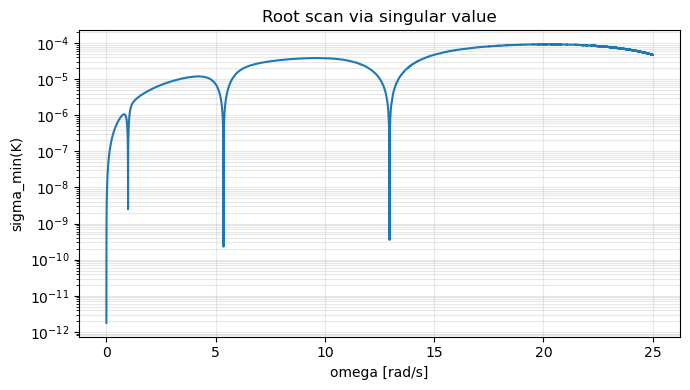

In [ ]:
# -----------------------------
# Natuurlijke frequenties via minima van sigma_min(ω)
# -----------------------------
def golden_minimize(f, a, b, n_iter=70):
    gr = (np.sqrt(5.0) - 1.0) / 2.0
    c1 = b - gr*(b-a)
    c2 = a + gr*(b-a)
    f1 = f(c1)
    f2 = f(c2)
    for _ in range(n_iter):
        if f1 < f2:
            b, c2, f2 = c2, c1, f1
            c1 = b - gr*(b-a)
            f1 = f(c1)
        else:
            a, c1, f1 = c1, c2, f2
            c2 = a + gr*(b-a)
            f2 = f(c2)
    x = 0.5*(a+b)
    return x, f(x)

def find_modes(n_modes=3, omega_max=25.0, n_grid=25000, sigma_tol=1e-8, min_spacing=5e-2):
    ws = np.linspace(1e-4, omega_max, n_grid)
    sig = np.array([sigma_min(w) for w in ws], dtype=float)

    refined = []
    for i in range(1, len(ws)-1):
        if sig[i] < sig[i-1] and sig[i] < sig[i+1]:
            a, b = ws[i-1], ws[i+1]
            w_star, s_star = golden_minimize(sigma_min, a, b)
            refined.append((float(w_star), float(s_star)))

    refined.sort(key=lambda t: t[0])
    unique = []
    for w_star, s_star in refined:
        if not unique or abs(w_star - unique[-1][0]) > min_spacing:
            unique.append((w_star, s_star))
        elif s_star < unique[-1][1]:
            unique[-1] = (w_star, s_star)

    physical = [(w, s) for (w, s) in unique if s < sigma_tol]
    physical.sort(key=lambda t: t[0])

    om = np.array([w for w, _ in physical[:n_modes]], dtype=float)
    sm = np.array([s for _, s in physical[:n_modes]], dtype=float)
    return om, sm, ws, sig

omega_n, sigma_n, omega_scan, sig_scan = find_modes(n_modes=3, sigma_tol=1e-8)
freq_n = omega_n/(2*np.pi)

print('Eerste 3 natuurlijke frequenties:')
for i, (om, fr, sg) in enumerate(zip(omega_n, freq_n, sigma_n), 1):
    print(f"mode {i}: omega = {om:.6f} rad/s | f = {fr:.6f} Hz | sigma_min = {sg:.2e}")

if len(omega_n) < 3:
    print(f"Waarschuwing: slechts {len(omega_n)} fysieke roots gevonden onder sigma_tol = 1e-8.")

plt.figure(figsize=(7,4))
plt.plot(omega_scan, sig_scan)
plt.yscale('log')
plt.xlabel('omega [rad/s]')
plt.ylabel('sigma_min(K)')
plt.title('Root scan via singular value')
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

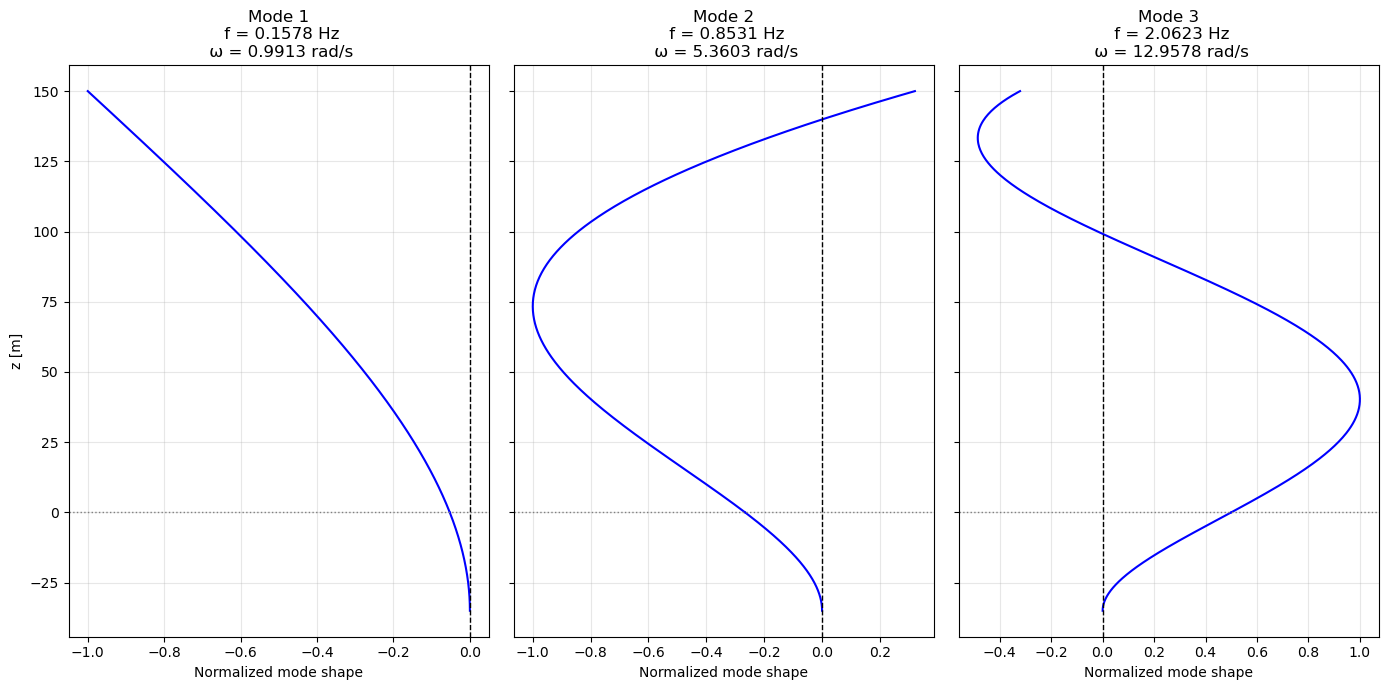

In [ ]:
# -----------------------------
# Eerste 3 modusvormen
# -----------------------------
W1_num = sp.simplify(W1.subs(vals))
W2_num = sp.simplify(W2.subs(vals))

W1_fun = sp.lambdify((z, omega, A1,B1,C1,D1,A2,B2,C2,D2), W1_num, 'numpy')
W2_fun = sp.lambdify((z, omega, A1,B1,C1,D1,A2,B2,C2,D2), W2_num, 'numpy')

def mode_constants(om):
    Kw = Knum(om)
    _, _, Vh = np.linalg.svd(Kw)
    cst = Vh.conj().T[:, -1]
    return cst/(np.max(np.abs(cst)) + 1e-16)

z1 = np.linspace(-h_num, 0.0, 300)
z2 = np.linspace(0.0, H_num, 400)

fig, axes = plt.subplots(1, 3, figsize=(14, 7), sharey=True)
for i, om in enumerate(omega_n[:3]):
    cst = mode_constants(om)
    A1v,B1v,C1v,D1v,A2v,B2v,C2v,D2v = cst

    phi1 = np.real(np.array(W1_fun(z1, om, A1v,B1v,C1v,D1v,A2v,B2v,C2v,D2v), dtype=np.complex128))
    phi2 = np.real(np.array(W2_fun(z2, om, A1v,B1v,C1v,D1v,A2v,B2v,C2v,D2v), dtype=np.complex128))

    norm = max(np.max(np.abs(phi1)), np.max(np.abs(phi2))) + 1e-16
    phi1 /= norm
    phi2 /= norm

    ax = axes[i]
    ax.plot(phi1, z1, 'b')
    ax.plot(phi2, z2, 'b')
    ax.axvline(0.0, color='k', linestyle='--', linewidth=1)
    ax.axhline(0.0, color='gray', linestyle=':', linewidth=1)
    ax.grid(True, alpha=0.3)
    ax.set_title(f"Mode {i+1}\n f = {om/(2*np.pi):.4f} Hz\n ω = {om:.4f} rad/s")
    ax.set_xlabel('Normalized mode shape')

axes[0].set_ylabel('z [m]')
plt.tight_layout()
plt.show()

### Opmerking
Voor vrije trillingen is demping niet meegenomen in de eigenwaarde-bepaling (c=0).
Dit is in lijn met de standaard slide-methode voor natuurlijke frequenties en modusvormen.

## Steady-state (slide-only)
Hieronder wordt de stationaire respons berekend met de **exacte 2-regio ODE-oplossing** uit (1.41)–(1.58), voor:
- regelmatige golf
- JONSWAP
- zonder en met top-dashpot

Per frequentie worden de 8 rand/interfacevoorwaarden direct opgelost voor de 8 onbekende constanten in $W_1$ en $W_2$.

In [9]:
# -----------------------------
# Steady-state settings + wave helpers
# -----------------------------
gamma_jonswap = 3.3

A_disp = np.pi * D_num**2 / 4.0
n_modes_ss = min(3, len(omega_n))

def solve_dispersion(omega_w, h_w, g_w=9.81):
    T_w = 2.0 * np.pi / omega_w
    return waveNumber_dispertionRelation_NewtonRhapson(T_w, h_w, tolerance=1e-10, g_w=g_w)

# Keep Ca from the global DNV selection used in free vibrations
Cm = 1.0 + float(Ca_num)

# DNV-RP-C205 §4.2.6 based Cd and gamma for the current sea state (Hs, Tp)
e_rough = K_rough / D_num
omega_p = 2.0 * np.pi / Tp
k_p = solve_dispersion(omega_p, h_num, g_num)
zeta_a = Hs / 2.0
u_a = omega_p * zeta_a / np.sinh(k_p * h_num)
KC = u_a * Tp / D_num

if KC < 5.0:
    if e_rough < 0.001:
        Cd_dnv = 1.2
    elif e_rough < 0.01:
        Cd_dnv = 1.1
    else:
        Cd_dnv = 1.0
elif KC < 10.0:
    if e_rough < 0.001:
        Cd_dnv = 1.1
    elif e_rough < 0.01:
        Cd_dnv = 1.0
    else:
        Cd_dnv = 0.9
else:
    Cd_dnv = 0.7

Cd_hydro = float(Cd_dnv)
gamma_hydro = float(D_num * u_a)

print(f"DNV steady-state coefficients: Ca={Ca_num:.3f}, Cm={Cm:.3f}, Cd={Cd_hydro:.3f}, gamma={gamma_hydro:.3f} m^2/s")
print(f"Supporting values: KC={KC:.3f}, e=K/D={e_rough:.5f}, u_a={u_a:.3f} m/s")

def regular_wave_line_load_amp(zq, omega_w, a_wave):
    k = solve_dispersion(omega_w, h_num, g_num)
    u_ddot = a_wave * omega_w**2 * np.cosh(k * (zq + h_num)) / np.sinh(k * h_num)
    return rho_f_num * Cm * A_disp * u_ddot

def jonswap(f, Hs_loc, Tp_loc, gamma=3.3):
    fp = 1.0 / Tp_loc
    alpha = 0.0624 / (0.230 + 0.0336*gamma - 0.185*(1.9 + gamma)**-1)
    tau = np.where(f <= fp, 0.07, 0.09)
    r = np.exp(-(f - fp)**2 / (2*tau**2*fp**2))
    S = (2*np.pi * alpha * Hs_loc**2
         * (f**(-5) / fp**(-4))
         * np.exp(-5/4 * (f/fp)**(-4))
         * gamma**r)
    return S

DNV steady-state coefficients: Ca=0.700, Cm=1.700, Cd=1.100, gamma=8.513 m^2/s
Supporting values: KC=1.596, e=K/D=0.00625, u_a=1.064 m/s


In [10]:
# -----------------------------
# Exact steady-state according to (1.41) to (1.58)
# -----------------------------
# Uses DNV-based Ca_num, Cm, Cd_hydro and gamma_hydro from the previous cell

# Extra symbols for forced solution
k_w = sp.symbols('k_w', positive=True, real=True)
a_w = sp.symbols('a_w', positive=True, real=True)
Cm_sym = sp.symbols('Cm_sym', positive=True, real=True)
Cd_sym = sp.symbols('Cd_sym', positive=True, real=True)
gamma_sym = sp.symbols('gamma_sym', positive=True, real=True)

A1s, B1s, C1s, D1s = sp.symbols('A1s B1s C1s D1s')
A2s, B2s, C2s, D2s = sp.symbols('A2s B2s C2s D2s')
unknowns_ss = [A1s, B1s, C1s, D1s, A2s, B2s, C2s, D2s]

beta_s4_ss = (omega**2 * (rho*A + rho_f*Ca*sp.pi*D**2/4) + sp.I*omega*(sp.Rational(1, 2))*rho_f*Cd_sym*gamma_sym) / (E*I)
beta4_ss = (omega**2 * rho * A) / (E*I)
beta_s_ss = beta_s4_ss**sp.Rational(1, 4)
beta_ss = beta4_ss**sp.Rational(1, 4)

Ux_ss = (
    -(1/(E*I)) * rho_f * Cm_sym * (sp.pi*D**2/4) * a_w * omega**2 * (1/sp.sinh(k_w*h)) * sp.exp(-sp.I*sp.pi/2)
    + (1/(2*E*I)) * rho_f * Cd_sym * gamma_sym * a_w * omega * (1/sp.sinh(k_w*h))
)

W1f_ss = Ux_ss / (k_w**4 - beta_s4_ss)

W1_ss = (
    A1s*sp.cosh(beta_s_ss*z) + B1s*sp.sinh(beta_s_ss*z)
    + C1s*sp.cos(beta_s_ss*z) + D1s*sp.sin(beta_s_ss*z)
    + W1f_ss*sp.cosh(k_w*(z+h))
)
W2_ss = (
    A2s*sp.cosh(beta_ss*z) + B2s*sp.sinh(beta_ss*z)
    + C2s*sp.cos(beta_ss*z) + D2s*sp.sin(beta_ss*z)
)

# Boundary and interface conditions (1.47) to (1.53)
bc1 = W1_ss.subs(z, -h)
bc2 = sp.diff(W1_ss, z).subs(z, -h)
bc3 = E*I*sp.diff(W2_ss, z, 2).subs(z, H) - J*omega**2*sp.diff(W2_ss, z).subs(z, H)
bc4 = E*I*sp.diff(W2_ss, z, 3).subs(z, H) + Mtip*omega**2*W2_ss.subs(z, H) + sp.I*omega*c*W2_ss.subs(z, H)
bc5 = W1_ss.subs(z, 0) - W2_ss.subs(z, 0)
bc6 = sp.diff(W1_ss, z).subs(z, 0) - sp.diff(W2_ss, z).subs(z, 0)
bc7 = sp.diff(W1_ss, z, 2).subs(z, 0) - sp.diff(W2_ss, z, 2).subs(z, 0)
bc8 = sp.diff(W1_ss, z, 3).subs(z, 0) - sp.diff(W2_ss, z, 3).subs(z, 0)

eqs_ss = [bc1, bc2, bc3, bc4, bc5, bc6, bc7, bc8]

def solve_component_W1_W2_exact(omega_force, a_wave, with_dashpot=False, Ca_loc=None, Cd_loc=None, gamma_loc=None):
    if Ca_loc is None:
        Ca_loc = Ca_num
    if Cd_loc is None:
        Cd_loc = Cd_hydro
    if gamma_loc is None:
        gamma_loc = gamma_hydro

    k_force = solve_dispersion(omega_force, h_num, g_num)
    c_aero = c_num if with_dashpot else 0.0

    params = {
        E: E_num, I: I_num, rho: rho_num, A: A_num,
        rho_f: rho_f_num, Ca: float(Ca_loc), D: D_num,
        h: h_num, H: H_num,
        J: J_num, Mtip: M_num, c: c_aero,
        omega: float(omega_force),
        k_w: float(k_force),
        a_w: float(a_wave),
        Cm_sym: 1.0 + float(Ca_loc),
        Cd_sym: float(Cd_loc),
        gamma_sym: float(gamma_loc),
    }

    eqs_num = [sp.N(eq.subs(params), 40) for eq in eqs_ss]
    M_mat, b_vec = sp.linear_eq_to_matrix(eqs_num, unknowns_ss)
    M_np = np.array(M_mat.evalf(30).tolist(), dtype=np.complex128)
    b_np = -np.array(b_vec.evalf(30).tolist(), dtype=np.complex128).reshape(-1)

    try:
        x = np.linalg.solve(M_np, b_np)
    except np.linalg.LinAlgError:
        x = np.linalg.lstsq(M_np, b_np, rcond=None)[0]

    subs_c = dict(zip(unknowns_ss, x))
    W1_num = sp.N(W1_ss.subs(params).subs(subs_c), 25)
    W2_num = sp.N(W2_ss.subs(params).subs(subs_c), 25)

    W1_fun_exact = sp.lambdify(z, W1_num, 'numpy')
    W2_fun_exact = sp.lambdify(z, W2_num, 'numpy')
    return W1_fun_exact, W2_fun_exact, k_force

def slide_harmonic_response(Tp_loc, with_dashpot=False, a_wave=None, phase=0.0):
    om = 2.0 * np.pi / Tp_loc
    a_loc = Hs / 2.0 if a_wave is None else a_wave

    _, W2_fun_exact, _ = solve_component_W1_W2_exact(
        omega_force=om,
        a_wave=a_loc,
        with_dashpot=with_dashpot,
        Ca_loc=Ca_num,
        Cd_loc=Cd_hydro,
        gamma_loc=gamma_hydro
    )

    # Continuity at z=0: W1(0)=W2(0), so evaluate response with W2
    w_swl_hat = W2_fun_exact(0.0) * np.exp(1j * phase)
    w_top_hat = W2_fun_exact(H_num) * np.exp(1j * phase)
    return om, w_swl_hat, w_top_hat

Slide regular |w_hat(SWL)| without damping = 0,003731 m
Slide regular |w_hat(Top)| without damping = 0,030994 m
Slide regular |w_hat(SWL)| with dashpot    = 0,003731 m
Slide regular |w_hat(Top)| with dashpot    = 0,030992 m
Maximum amplitude z=0 (without dashpot) = 0,003731 m
Maximum amplitude z=H (without dashpot) = 0,030994 m
Maximum amplitude z=0 (with dashpot)    = 0,003731 m
Maximum amplitude z=H (with dashpot)    = 0,030992 m


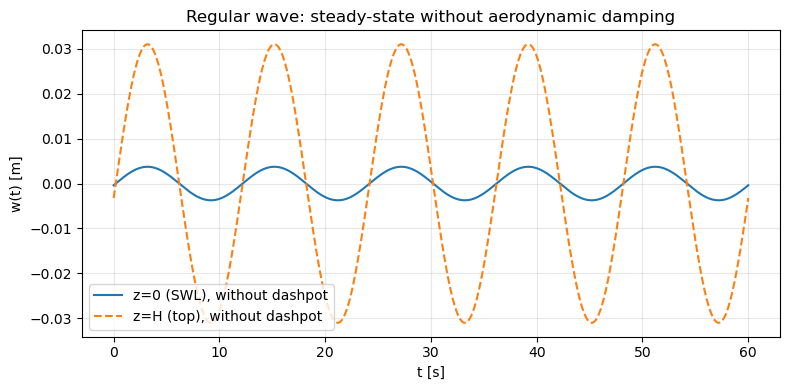

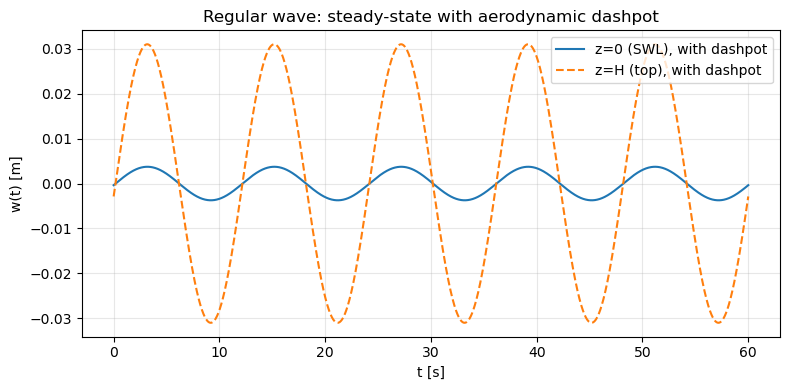

In [11]:
# -----------------------------
# Regular wave steady-state (slide-only)
# -----------------------------
omega_reg, w_swl_reg, w_top_reg = slide_harmonic_response(Tp, with_dashpot=False)
_, w_swl_reg_d, w_top_reg_d = slide_harmonic_response(Tp, with_dashpot=True)

fmt = lambda x: f"{float(x):.6f}".replace('.', ',')

print(f"Slide regular |w_hat(SWL)| without damping = {fmt(abs(w_swl_reg))} m")
print(f"Slide regular |w_hat(Top)| without damping = {fmt(abs(w_top_reg))} m")
print(f"Slide regular |w_hat(SWL)| with dashpot    = {fmt(abs(w_swl_reg_d))} m")
print(f"Slide regular |w_hat(Top)| with dashpot    = {fmt(abs(w_top_reg_d))} m")

t_reg = np.linspace(0.0, 5.0 * Tp, 2000)
w_swl_reg_t = np.real(w_swl_reg * np.exp(1j * omega_reg * t_reg))
w_top_reg_t = np.real(w_top_reg * np.exp(1j * omega_reg * t_reg))
w_swl_reg_d_t = np.real(w_swl_reg_d * np.exp(1j * omega_reg * t_reg))
w_top_reg_d_t = np.real(w_top_reg_d * np.exp(1j * omega_reg * t_reg))

print(f"Maximum amplitude z=0 (without dashpot) = {fmt(np.max(np.abs(w_swl_reg_t)))} m")
print(f"Maximum amplitude z=H (without dashpot) = {fmt(np.max(np.abs(w_top_reg_t)))} m")
print(f"Maximum amplitude z=0 (with dashpot)    = {fmt(np.max(np.abs(w_swl_reg_d_t)))} m")
print(f"Maximum amplitude z=H (with dashpot)    = {fmt(np.max(np.abs(w_top_reg_d_t)))} m")

# Step 3: without aerodynamic damping, at z=0 and z=H
plt.figure(figsize=(8, 4))
plt.plot(t_reg, w_swl_reg_t, label='z=0 (SWL), without dashpot')
plt.plot(t_reg, w_top_reg_t, '--', label='z=H (top), without dashpot')
plt.xlabel('t [s]')
plt.ylabel('w(t) [m]')
plt.title('Regular wave: steady-state without aerodynamic damping')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Additional check: with dashpot
plt.figure(figsize=(8, 4))
plt.plot(t_reg, w_swl_reg_d_t, label='z=0 (SWL), with dashpot')
plt.plot(t_reg, w_top_reg_d_t, '--', label='z=H (top), with dashpot')
plt.xlabel('t [s]')
plt.ylabel('w(t) [m]')
plt.title('Regular wave: steady-state with aerodynamic dashpot')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

JONSWAP RMS z=0 without damping = 0,004972 m
JONSWAP RMS z=H without damping = 0,045060 m
JONSWAP RMS z=0 with dashpot    = 0,004972 m
JONSWAP RMS z=H with dashpot    = 0,045066 m
Maximum amplitude eta            = 8,197232 m
Maximum amplitude z=0 (no damp) = 0,011805 m
Maximum amplitude z=H (no damp) = 0,107239 m
Maximum amplitude z=0 (damped)  = 0,011810 m
Maximum amplitude z=H (damped)  = 0,107329 m


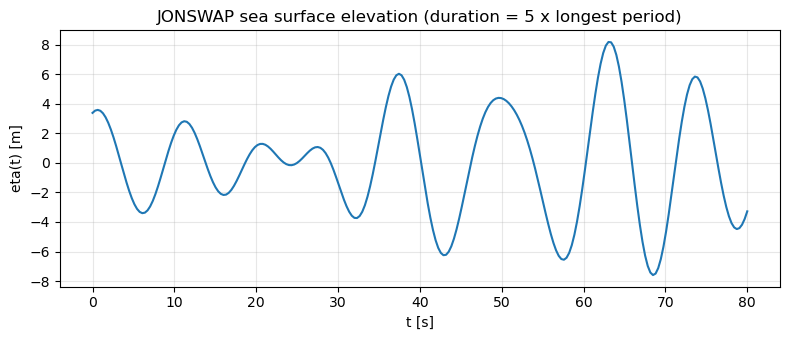

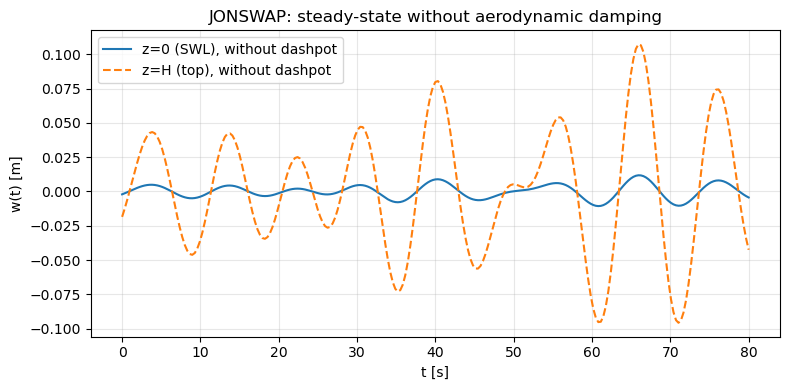

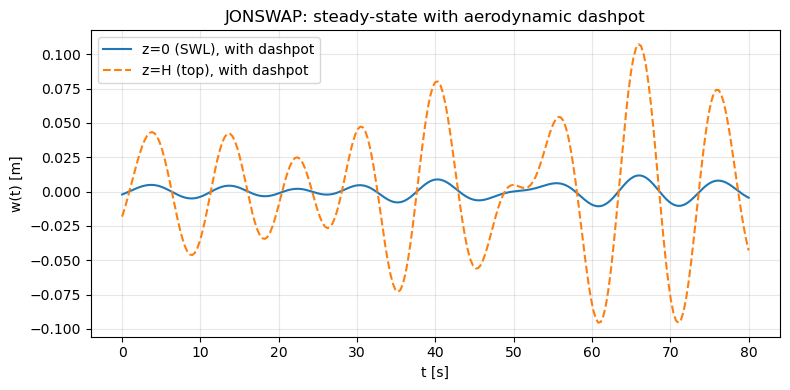

In [12]:
# -----------------------------
# JONSWAP steady-state (slide-only)
# -----------------------------
N_comp = 6
fp = 1.0 / Tp
freqs_samp = np.linspace(0.75 * fp, 1.4 * fp, N_comp)
omegas_samp = 2.0 * np.pi * freqs_samp
df = freqs_samp[1] - freqs_samp[0]
S_samp = jonswap(freqs_samp, Hs, Tp, gamma=gamma_jonswap)
amps_eta = np.sqrt(2.0 * S_samp * df)

np.random.seed(6)
phases = np.random.uniform(0.0, 2.0 * np.pi, N_comp)

T_max = 1.0 / freqs_samp[0]
t_end = 5.0 * T_max
dt = T_max / 50.0
t = np.arange(0.0, t_end + dt, dt)

eta = np.zeros_like(t)
w_swl_jonswap = np.zeros_like(t)
w_top_jonswap = np.zeros_like(t)
w_swl_jonswap_d = np.zeros_like(t)
w_top_jonswap_d = np.zeros_like(t)

for amp_i, om_i, ph_i in zip(amps_eta, omegas_samp, phases):
    Tp_i = 2.0 * np.pi / om_i
    _, w_swl_hat_i, w_top_hat_i = slide_harmonic_response(Tp_i, with_dashpot=False, a_wave=amp_i, phase=ph_i)
    _, w_swl_hat_i_d, w_top_hat_i_d = slide_harmonic_response(Tp_i, with_dashpot=True, a_wave=amp_i, phase=ph_i)

    eta += amp_i * np.cos(om_i * t + ph_i)
    w_swl_jonswap += np.real(w_swl_hat_i * np.exp(1j * om_i * t))
    w_top_jonswap += np.real(w_top_hat_i * np.exp(1j * om_i * t))
    w_swl_jonswap_d += np.real(w_swl_hat_i_d * np.exp(1j * om_i * t))
    w_top_jonswap_d += np.real(w_top_hat_i_d * np.exp(1j * om_i * t))

fmt = lambda x: f"{float(x):.6f}".replace('.', ',')

print(f"JONSWAP RMS z=0 without damping = {fmt(np.sqrt(np.mean(w_swl_jonswap**2)))} m")
print(f"JONSWAP RMS z=H without damping = {fmt(np.sqrt(np.mean(w_top_jonswap**2)))} m")
print(f"JONSWAP RMS z=0 with dashpot    = {fmt(np.sqrt(np.mean(w_swl_jonswap_d**2)))} m")
print(f"JONSWAP RMS z=H with dashpot    = {fmt(np.sqrt(np.mean(w_top_jonswap_d**2)))} m")

print(f"Maximum amplitude eta            = {fmt(np.max(np.abs(eta)))} m")
print(f"Maximum amplitude z=0 (no damp) = {fmt(np.max(np.abs(w_swl_jonswap)))} m")
print(f"Maximum amplitude z=H (no damp) = {fmt(np.max(np.abs(w_top_jonswap)))} m")
print(f"Maximum amplitude z=0 (damped)  = {fmt(np.max(np.abs(w_swl_jonswap_d)))} m")
print(f"Maximum amplitude z=H (damped)  = {fmt(np.max(np.abs(w_top_jonswap_d)))} m")

# Step 4: sea surface elevation
plt.figure(figsize=(8, 3.5))
plt.plot(t, eta)
plt.xlabel('t [s]')
plt.ylabel('eta(t) [m]')
plt.title('JONSWAP sea surface elevation (duration = 5 x longest period)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Step 5: without aerodynamic damping, at z=0 and z=H
plt.figure(figsize=(8, 4))
plt.plot(t, w_swl_jonswap, label='z=0 (SWL), without dashpot')
plt.plot(t, w_top_jonswap, '--', label='z=H (top), without dashpot')
plt.xlabel('t [s]')
plt.ylabel('w(t) [m]')
plt.title('JONSWAP: steady-state without aerodynamic damping')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Step 6: with aerodynamic dashpot, at z=0 and z=H
plt.figure(figsize=(8, 4))
plt.plot(t, w_swl_jonswap_d, label='z=0 (SWL), with dashpot')
plt.plot(t, w_top_jonswap_d, '--', label='z=H (top), with dashpot')
plt.xlabel('t [s]')
plt.ylabel('w(t) [m]')
plt.title('JONSWAP: steady-state with aerodynamic dashpot')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Gevoeligheidsanalyse axiale kracht T
Vergelijking van twee aannames:
- Case A: `T = 0`
- Case B: `T = M*g`
We vergelijken de eerste 3 natuurlijke frequenties en het relatieve verschil.

Case A: T = 0 N
Case B: T = M*g = 9.810e+06 N

Mode | f(T=0) [Hz] | f(T=M*g) [Hz] | Delta [%]
-----|-------------|---------------|----------
   1 |    0.157770 |      0.157154 |   -0.390
   2 |    0.853114 |      0.854409 |    0.152
   3 |    2.062152 |      2.063774 |    0.079


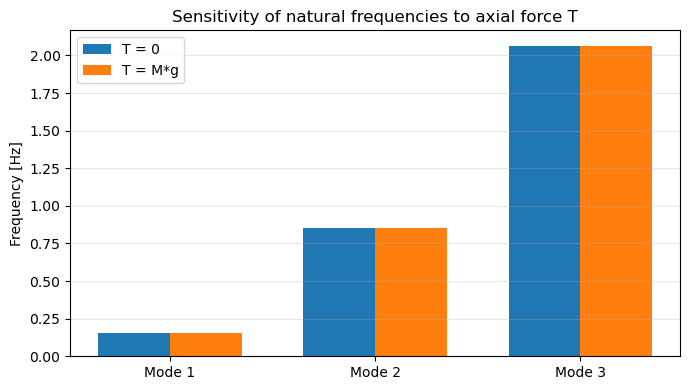

In [13]:
# -----------------------------
# Sensitivity T: T=0 vs T=M*g
# -----------------------------
def sigma_min_for_T_factory(T_case):
    vals_case = {
        E: E_num, I: I_num, T: float(T_case),
        rho: rho_num, A: A_num,
        rho_f: rho_f_num, Ca: Ca_num, D: D_num,
        h: h_num, H: H_num,
        J: J_num, Mtip: M_num, c: 0.0
    }
    K_case = K.subs(vals_case)
    K_fun_case = sp.lambdify(omega, K_case, modules='numpy')

    def sigma_min_case(w):
        K_np = np.array(K_fun_case(float(w)), dtype=np.complex128)
        svals = np.linalg.svd(K_np, compute_uv=False)
        return float(np.min(svals))

    return sigma_min_case

def find_modes_for_T(T_case, n_modes=3, omega_max=25.0, n_grid=12000, sigma_tol=1e-8, min_spacing=5e-2):
    sigma_fun = sigma_min_for_T_factory(T_case)
    ws = np.linspace(1e-4, omega_max, n_grid)
    sig = np.array([sigma_fun(w) for w in ws], dtype=float)

    refined = []
    for i in range(1, len(ws)-1):
        if sig[i] < sig[i-1] and sig[i] < sig[i+1]:
            a, b = ws[i-1], ws[i+1]
            w_star, s_star = golden_minimize(sigma_fun, a, b, n_iter=55)
            refined.append((float(w_star), float(s_star)))

    refined.sort(key=lambda t: t[0])
    unique = []
    for w_star, s_star in refined:
        if not unique or abs(w_star - unique[-1][0]) > min_spacing:
            unique.append((w_star, s_star))
        elif s_star < unique[-1][1]:
            unique[-1] = (w_star, s_star)

    physical = [(w, s) for (w, s) in unique if s < sigma_tol]
    physical.sort(key=lambda t: t[0])

    omega_modes = np.array([w for w, _ in physical[:n_modes]], dtype=float)
    sigma_modes = np.array([s for _, s in physical[:n_modes]], dtype=float)
    freq_modes = omega_modes / (2.0*np.pi)
    return omega_modes, freq_modes, sigma_modes

T_case_0 = 0.0
T_case_Mg = M_num * g_num

om_0, f_0, s_0 = find_modes_for_T(T_case_0, n_modes=3)
om_Mg, f_Mg, s_Mg = find_modes_for_T(T_case_Mg, n_modes=3)

n_cmp = min(len(f_0), len(f_Mg), 3)
if n_cmp < 3:
    print(f"Waarschuwing: slechts {n_cmp} vergelijkbare modes gevonden in beide T-cases.")

print(f"Case A: T = 0 N")
print(f"Case B: T = M*g = {T_case_Mg:.3e} N")
print("\nMode | f(T=0) [Hz] | f(T=M*g) [Hz] | Delta [%]")
print("-----|-------------|---------------|----------")
for i in range(n_cmp):
    delta_pct = 100.0 * (f_Mg[i] - f_0[i]) / (f_0[i] + 1e-16)
    print(f"{i+1:>4d} | {f_0[i]:>11.6f} | {f_Mg[i]:>13.6f} | {delta_pct:>8.3f}")

modes = np.arange(1, n_cmp+1)
width = 0.35
plt.figure(figsize=(7,4))
plt.bar(modes - width/2, f_0[:n_cmp], width=width, label='T = 0')
plt.bar(modes + width/2, f_Mg[:n_cmp], width=width, label='T = M*g')
plt.xticks(modes, [f'Mode {i}' for i in modes])
plt.ylabel('Frequency [Hz]')
plt.title('Sensitivity of natural frequencies to axial force T')
plt.grid(True, axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()